# Param M times

### Setup

In [1]:
%%capture
%pip install numpy matplotlib statsmodels arch joblib

In [2]:
import numpy as np, statsmodels.api as sm, warnings, matplotlib.pyplot as plt
from arch import arch_model
from joblib import Parallel, delayed
warnings.filterwarnings("ignore")

def winkler(y, m, v, a=0.05):
    d = 1.96 * np.sqrt(v); l, u = m-d, m+d
    return (u-l) + 40*max(l-y, 0) + 40*max(y-u, 0)

### Inputs

In [3]:
np.random.seed(42)

N, M = 5000, 3
P, mu, phi, sig = [[0.98, 0.02], [0.05, 0.95]], [0.0, 0.0], [0.9, 0.2], [0.1, 1.5]

paths = []
for _ in range(M):
    s, y = [0], [0.]
    for t in range(1, N):
        s.append(np.random.choice([0, 1], p=P[s[-1]]))
        y.append(mu[s[-1]] + phi[s[-1]] * y[-1] + np.random.normal(0, sig[s[-1]]))
    paths.append(np.array(y))

### Paths

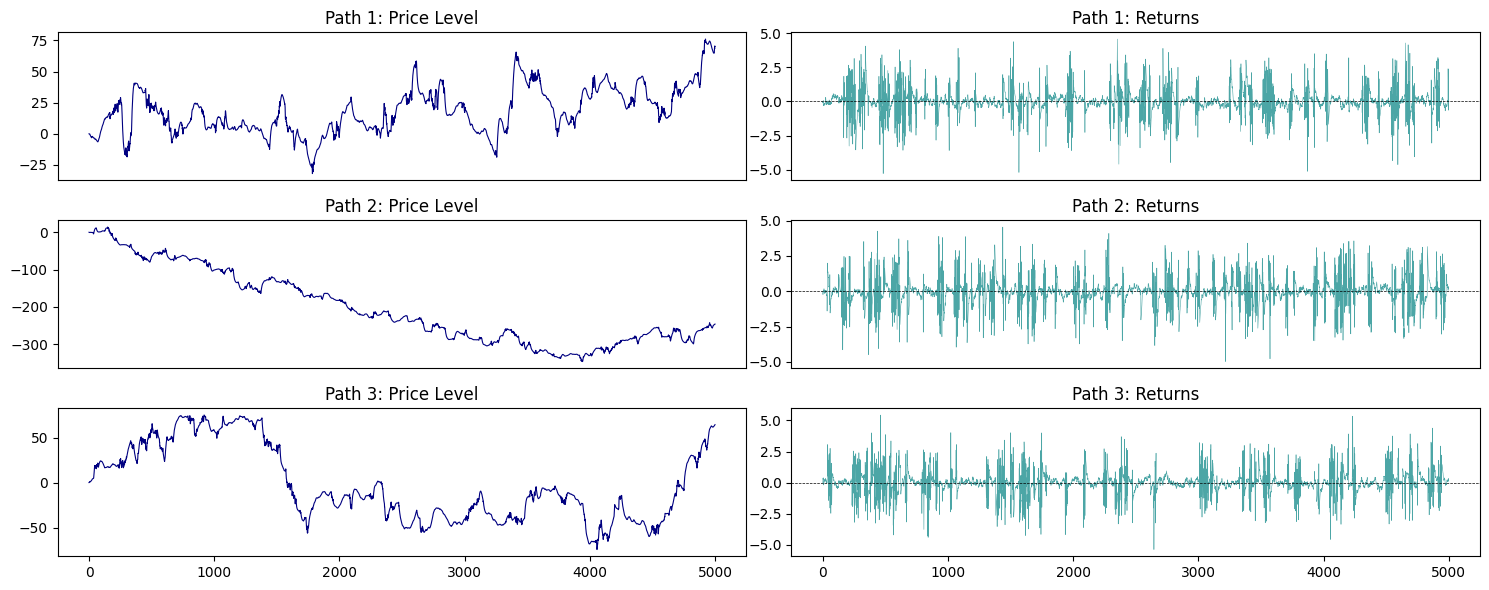

In [4]:
plt.figure(figsize=(15, 2 * M))

for i, y in enumerate(paths):
    # Column 1: Price Level (Cumulative Sum)
    plt.subplot(M, 2, 2*i + 1)
    plt.plot(np.cumsum(y), lw=0.8, color='navy')
    plt.title(f"Path {i+1}: Price Level")
    if i < M - 1: plt.xticks([])
    
    # Column 2: Returns (The Volatility)
    plt.subplot(M, 2, 2*i + 2)
    plt.plot(y, lw=0.4, color='teal', alpha=0.7)
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.title(f"Path {i+1}: Returns")
    if i < M - 1: plt.xticks([])

plt.tight_layout()
plt.show()

### Multi-path backtest

In [5]:
from joblib import Parallel, delayed

# 1. CONFIGURATION
window = 50
sweeps = {
    "AR(1)": ("ar", 1), "AR(3)": ("ar", 3),
    "ARCH(1)": ("arch", 1), "ARCH(3)": ("arch", 3), 
    "GARCH(1,1)": ("garch", (1,1)), "GARCH(2,2)": ("garch", (2,2)),
    "MSAR-O1": ("ms", 1), "MSAR-O2": ("ms", 2), "MSAR-O3": ("ms", 3)
}

all_results = {k: [] for k in sweeps}
recovered = []

# 2. THE WORKER FUNCTION (Now tracks failures!)
def process_step(tr, act, sweeps, is_last_step):
    step_results = {}
    failed_models = []
    last_params = None
    for name, (m_type, val) in sweeps.items():
        try:
            if m_type == "ar":
                m = sm.tsa.AutoReg(tr, val).fit()
                step_results[name] = [m.predict(len(tr), len(tr))[0], m.sigma2]
            elif m_type in ["arch", "garch"]:
                p, q = (val, 0) if m_type == "arch" else val
                m = arch_model(tr, vol='Garch', p=p, q=q).fit(disp='off')
                f = m.forecast(horizon=1)
                step_results[name] = [f.mean.values[-1,0], f.variance.values[-1,0]]
            elif m_type == "ms":
                m = sm.tsa.MarkovAutoregression(tr, k_regimes=2, order=val, switching_variance=True).fit(disp=False)
                p_nxt = np.asarray(m.regime_transition).reshape(2,2) @ np.asarray(m.filtered_marginal_probabilities)[-1].flatten()
                lags = tr[-val:][::-1]
                mu_regimes = [m.params[2+r] + np.dot(m.params[4+r:4+2*val:2], lags) for r in range(2)]
                step_results[name] = [np.dot(p_nxt, mu_regimes), np.dot(p_nxt, m.params[-2:])]
                if is_last_step: last_params = m.params
        except Exception as e:
            failed_models.append(name) # Log the failure quietly
            continue
            
    return step_results, last_params, failed_models

# 3. THE EXECUTION
print(f"🚀 Parallelizing sweep: {len(sweeps)} models across {M} paths...")
for p_idx, path in enumerate(paths):
    print(f"\n" + "="*50)
    print(f"🔥 Processing Path {p_idx+1}/{M}...")
    print("="*50)
    
    # verbose=10 forces Joblib to print progress updates (e.g., "Done 10 out of 50 tasks")
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_step)(path[:-i], path[-i], sweeps, i == 1) 
        for i in range(window, 0, -1)
    )
    
    # Reassemble results and count failures
    path_failures = {k: 0 for k in sweeps}
    
    for step_res, params, fails in results:
        if params is not None: recovered.append(params)
        for f in fails: path_failures[f] += 1
        for name in sweeps:
            if name in step_res:
                all_results[name].append(step_res[name])

    # Print out the health report for this path
    print(f"\n📊 Path {p_idx+1} Health Report (Out of {window} steps):")
    for mod, fails in path_failures.items():
        if fails == 0:
            print(f"  ✅ {mod}: 100% Success")
        else:
            print(f"  ❌ {mod}: Failed {fails} times (Optimizer couldn't converge)")

print("\n✅ Parallel Sweep Complete. Move to the Summary Cell!")

🚀 Parallelizing sweep: 9 models across 3 paths...

🔥 Processing Path 1/3...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   40.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:  3.8min remaining:   50.5s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  4.0min remaining:   15.3s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  4.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.



📊 Path 1 Health Report (Out of 50 steps):
  ✅ AR(1): 100% Success
  ✅ AR(3): 100% Success
  ✅ ARCH(1): 100% Success
  ✅ ARCH(3): 100% Success
  ✅ GARCH(1,1): 100% Success
  ✅ GARCH(2,2): 100% Success
  ✅ MSAR-O1: 100% Success
  ✅ MSAR-O2: 100% Success
  ✅ MSAR-O3: 100% Success

🔥 Processing Path 2/3...


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   35.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:  3.5min remaining:   46.3s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  3.6min remaining:   13.9s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  4.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.



📊 Path 2 Health Report (Out of 50 steps):
  ✅ AR(1): 100% Success
  ✅ AR(3): 100% Success
  ✅ ARCH(1): 100% Success
  ✅ ARCH(3): 100% Success
  ✅ GARCH(1,1): 100% Success
  ✅ GARCH(2,2): 100% Success
  ✅ MSAR-O1: 100% Success
  ✅ MSAR-O2: 100% Success
  ✅ MSAR-O3: 100% Success

🔥 Processing Path 3/3...


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   34.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:  3.5min remaining:   46.4s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  3.6min remaining:   13.9s



📊 Path 3 Health Report (Out of 50 steps):
  ✅ AR(1): 100% Success
  ✅ AR(3): 100% Success
  ✅ ARCH(1): 100% Success
  ✅ ARCH(3): 100% Success
  ✅ GARCH(1,1): 100% Success
  ✅ GARCH(2,2): 100% Success
  ✅ MSAR-O1: 100% Success
  ✅ MSAR-O2: 100% Success
  ✅ MSAR-O3: 100% Success

✅ Parallel Sweep Complete. Move to the Summary Cell!


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  3.9min finished


### Analysis

In [6]:
def analyze(y, p, v):
    y, p, v = np.array(y), np.array(p), np.array(v)
    s, rets = np.sqrt(v), np.sign(p) * y
    return [np.mean((y-p)**2), np.mean([winkler(yi, pi, vi) for yi, pi, vi in zip(y, p, v)]), 
            np.mean((y >= p-1.96*s) & (y <= p+1.96*s)), np.mean(np.sign(y) == np.sign(p)), 
            (np.mean(rets)/np.std(rets))*np.sqrt(252) if np.std(rets)>0 else 0, np.sum(rets)]

h = ["MSE", "Winkler", "Cov95", "HitRate", "Sharpe", "TotRet"]
print(f"{'MODEL':<12} | " + " | ".join(h))
print("-" * 80)

summary = {}
for mod in all_results:
    m_list = [analyze(path[-window:], np.array(pv)[:,0], np.array(pv)[:,1]) for pv in all_results[mod] if len(pv)==window]
    if not m_list: continue
    avg = np.mean(m_list, axis=0)
    summary[mod] = avg
    print(f"{mod:<12} | " + " | ".join(f"{v:.3f}" for v in avg))

print("\n" + "="*30 + "\nPARAM RECOVERY (True vs Est)\n" + "="*30)
rp = np.mean(recovered, axis=0)
print(f"True Phi: {phi} | Est: {rp[4:6].round(2)}")
print(f"True Sig2: {[round(x**2, 3) for x in sig]} | Est: {rp[-2:].round(3)}")

MODEL        | MSE | Winkler | Cov95 | HitRate | Sharpe | TotRet
--------------------------------------------------------------------------------

PARAM RECOVERY (True vs Est)
True Phi: [0.9, 0.2] | Est: [0.01 2.47]
True Sig2: [0.01, 2.25] | Est: [-0.001  0.134]


### Viz

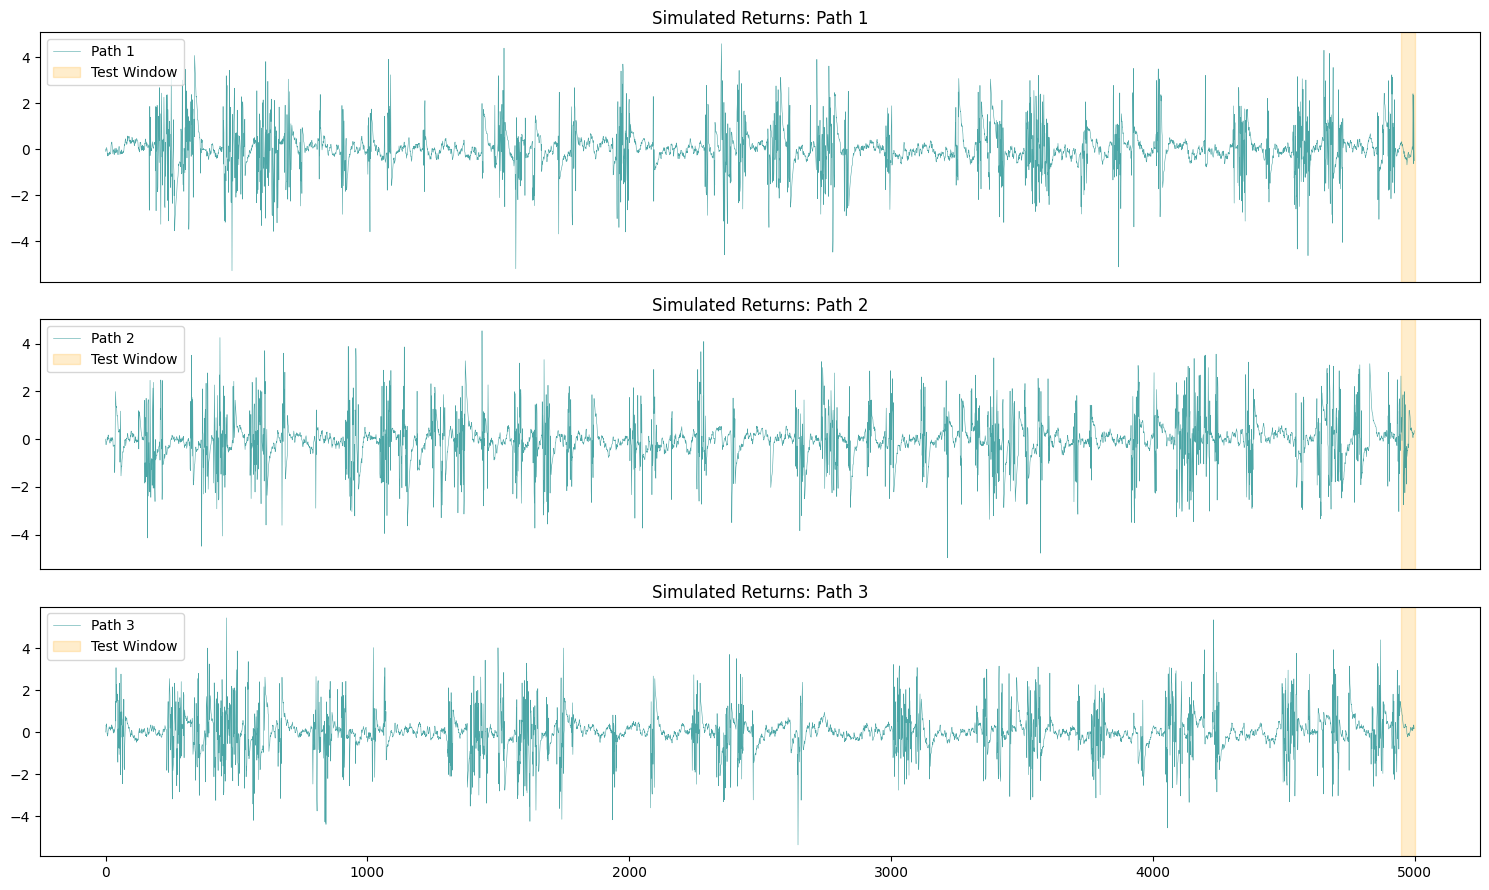

In [7]:
plt.figure(figsize=(15, 3 * M))
for i, path in enumerate(paths):
    plt.subplot(M, 1, i + 1)
    # Plot the full return series
    plt.plot(path, color='teal', lw=0.4, alpha=0.7, label=f"Path {i+1}")
    # Highlight the test window (the last 50 points we backtested)
    plt.axvspan(len(path)-window, len(path), color='orange', alpha=0.2, label='Test Window')
    plt.title(f"Simulated Returns: Path {i+1}")
    plt.legend(loc='upper left')
    if i < M-1: plt.xticks([])

plt.tight_layout(); plt.show()